In [ ]:
import numpy as np
from road_gen.integrator.integrator import integrate_road
from road_gen.plotting.plot_road import plot_road

# Describing a road as a planar curve

Let $r(s)$ be a [planar curve](https://en.wikipedia.org/wiki/Plane_curve) describing a road in the xy-plane as a function of *arc length* $s$ (distance traveled along the road), where $s \in [0, L]$.
Suppose a road of total length $L$ in the xy-plane. Let the distance traveled along the road be denoted $s$ where $s \in [0, L]$.

Let $\kappa(s)$ be the curvature of $r(s)$

$$
\kappa(s) = \frac{d\theta}{ds}
$$

where $\theta$ is the heading (direction) of the road. Basically, $\kappa(s)$ tells us at arc length $s$ whether the path is about to turn left or right, with larger magnitude of $\kappa(s)$ indicating a sharper change, and $\kappa(s) = 0$ indicating no change. A path in the xy-plane can now be fully defined by $\kappa(s)$ and $L$, as the heading angle is simply

$$
\theta(s) = \int_0^s \kappa(u)~du
$$

and

$$
x(s) = \int_0^s \cos(\theta(u))~du \; , \; y(s) = \int_0^s \sin(\theta(u))~du
$$

#### Discrete form

In practice, if we are going to generate a road in computer code we need to discretize this above formulation. Suppose a step size $\Delta s$, then at the $i$-th waypoint we have traveled a distance $s_i = i \Delta s$ and we have $N = L/\Delta s$ waypoints in total. At waypoint $i$, with known curvature $\kappa_i$, the next heading is

$$
\theta_{i+1} = \theta_i + \kappa_i \Delta s
$$

which by recursion means that

$$
\theta_{i+1} = \sum_{j=0}^i \theta_j + \kappa_j \Delta s
$$

and likewise

$$
x_{i+1} = \sum_{j=0}^i x_j \cos(\theta_j) \Delta s \; , \; y_{i+1} = \sum_{j=0}^i y_j \sin(\theta_j) \Delta s.
$$

This shows that with starting conditions $(x_0, y_0, \theta_0)$ and discrete curvature field $\{\kappa_0, \kappa_1 ... \kappa_{N-1}\}$ we can construct a path of any arbitrary length $L$ with its shape entirely determined by the curvature field.

# Visualizing curvature effect on final road composition

#### Straight road
A straight road can be defined by using curvature $\kappa_i = 0$ at every step $i$; this would produce a straight road of length $L$ in the direction of the intitial heading $\theta_0$.

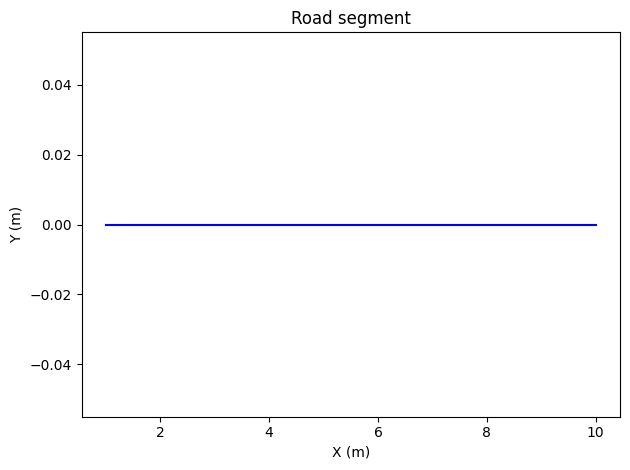

In [5]:

curvature = np.zeros(10)
x, y = integrate_road(curvature)
plot_road(x, y)

#### Instant turn

We could add a turn by setting $\kappa \neq 0$ somewhere along the curvature.

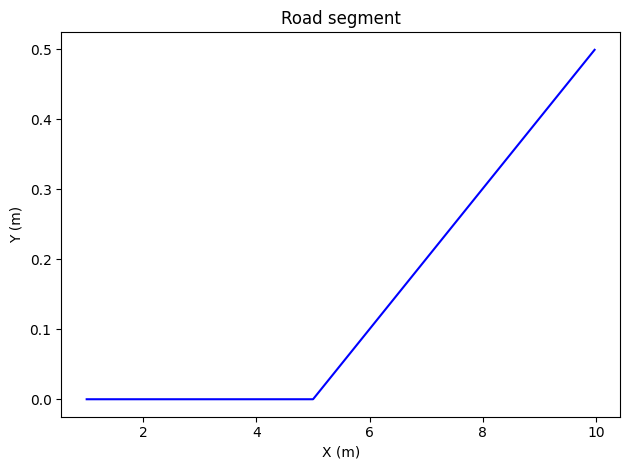

In [6]:

curvature[4] = 0.1
x, y = integrate_road(curvature)
plot_road(x, y)

#### Smooth turn

A smooth turn would look like curvature being constant for a few steps.

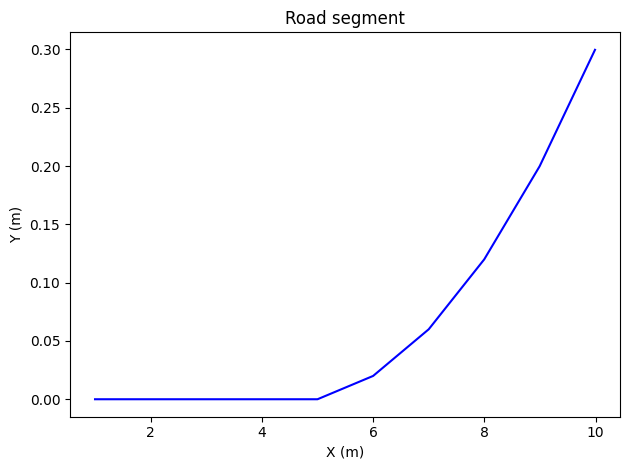

In [7]:
curvature = np.zeros(10)
curvature[4:] = 0.02
x, y = integrate_road(curvature)
plot_road(x, y)